In [2]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append('../src')
from model import GraphSAGE

print('Loading graph and model...')
data   = torch.load('../data/processed/transaction_graph.pt', weights_only=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = GraphSAGE(input_dim=data.num_features).to(device)
model.load_state_dict(torch.load('../best_model.pt', map_location=device))
model.eval()
data = data.to(device)

with torch.no_grad():
    out   = model(data.x, data.edge_index)
    probs = torch.exp(out[:, 1]).cpu().numpy()

y_true     = data.y.cpu().numpy()
edge_index = data.edge_index.cpu().numpy()

print(f'Nodes: {data.num_nodes:,}  |  Edges: {data.num_edges:,}')
print(f'Fraud nodes: {y_true.sum():,}')

Loading graph and model...
Nodes: 50,000  |  Edges: 1,143,408
Fraud nodes: 1,793


In [3]:
fraud_indices = np.where(y_true == 1)[0]

edge_src = edge_index[0]
fraud_degree = {}
for f in fraud_indices:
    fraud_degree[f] = (edge_src == f).sum()

center_node = max(fraud_degree, key=fraud_degree.get)
print(f'Center fraud node : {center_node}')
print(f'Degree            : {fraud_degree[center_node]}')
print(f'Fraud probability : {probs[center_node]:.4f}')

Center fraud node : 32461
Degree            : 239
Fraud probability : 0.9681


In [4]:
def get_neighbors(node, edge_index):
    mask = edge_index[0] == node
    return set(edge_index[1][mask].tolist())

hop1 = get_neighbors(center_node, edge_index)
hop2 = set()
for n in hop1:
    hop2.update(get_neighbors(n, edge_index))

subgraph_nodes = {center_node} | hop1 | hop2
if len(subgraph_nodes) > 80:
    hop2_sample    = set(list(hop2)[:80 - len(hop1) - 1])
    subgraph_nodes = {center_node} | hop1 | hop2_sample

print(f'Subgraph size : {len(subgraph_nodes)} nodes')
print(f'Fraud in sub  : {sum(y_true[n]==1 for n in subgraph_nodes)}')
print(f'Legit in sub  : {sum(y_true[n]==0 for n in subgraph_nodes)}')

Subgraph size : 3363 nodes
Fraud in sub  : 132
Legit in sub  : 3231


In [5]:
G = nx.DiGraph()
G.add_nodes_from(subgraph_nodes)

for i in range(edge_index.shape[1]):
    src, dst = edge_index[0][i], edge_index[1][i]
    if src in subgraph_nodes and dst in subgraph_nodes:
        G.add_edge(src, dst)

print(f'Subgraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Subgraph: 3363 nodes, 194442 edges


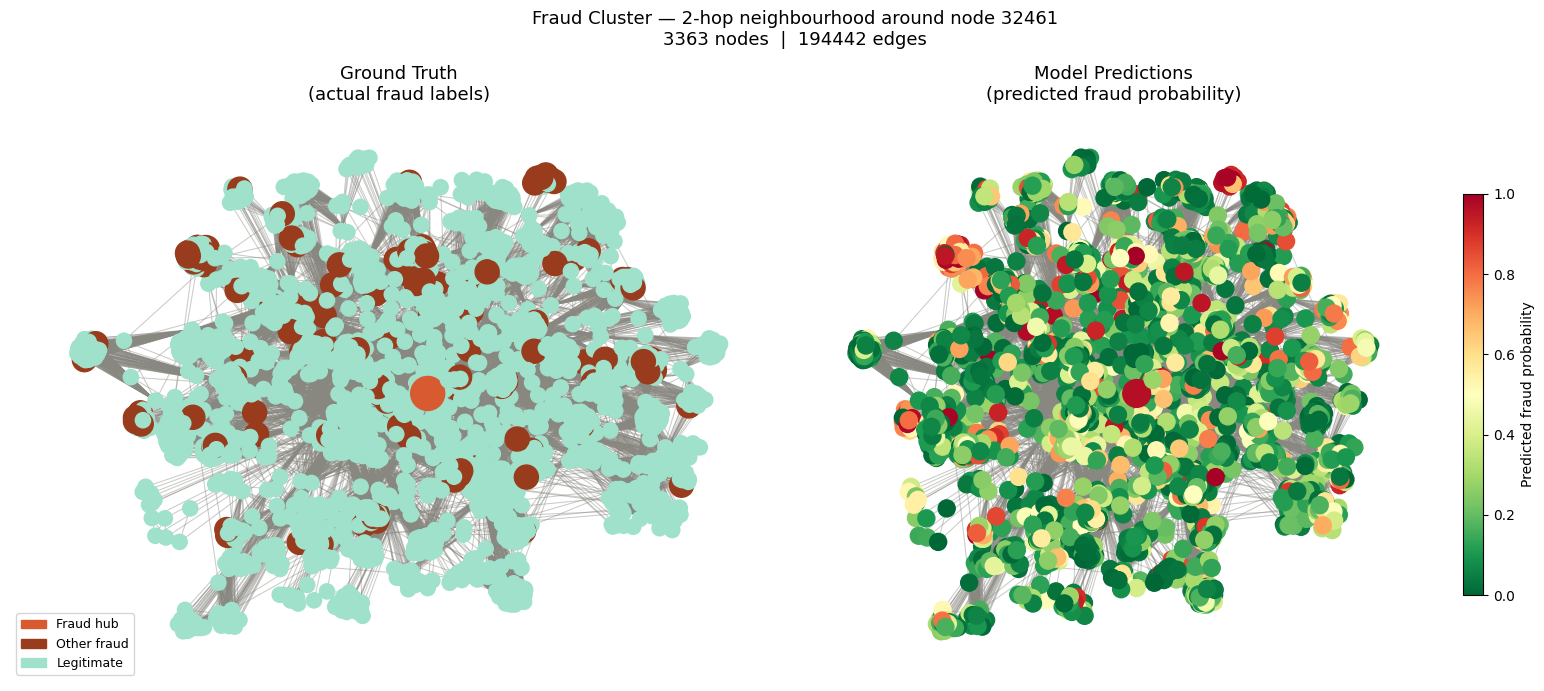

Saved: fraud_subgraph.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
pos       = nx.spring_layout(G, seed=42, k=1.2)
node_list = list(G.nodes())

# Left — ground truth
ax1 = axes[0]
node_colors_true = []
node_sizes_true  = []
for n in node_list:
    if n == center_node:
        node_colors_true.append('#D85A30'); node_sizes_true.append(600)
    elif y_true[n] == 1:
        node_colors_true.append('#993C1D'); node_sizes_true.append(300)
    else:
        node_colors_true.append('#9FE1CB'); node_sizes_true.append(120)

nx.draw_networkx_edges(G, pos, ax=ax1, alpha=0.25,
                       edge_color='#888780', arrows=False, width=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax1, nodelist=node_list,
                       node_color=node_colors_true, node_size=node_sizes_true)
ax1.set_title('Ground Truth\n(actual fraud labels)', fontsize=13)
ax1.axis('off')
ax1.legend(handles=[
    mpatches.Patch(color='#D85A30', label='Fraud hub'),
    mpatches.Patch(color='#993C1D', label='Other fraud'),
    mpatches.Patch(color='#9FE1CB', label='Legitimate'),
], loc='lower left', fontsize=9)

# Right — model predictions
ax2 = axes[1]
node_probs     = [probs[n] for n in node_list]
node_sizes_pred = [400 if n == center_node else 150 for n in node_list]

nx.draw_networkx_edges(G, pos, ax=ax2, alpha=0.25,
                       edge_color='#888780', arrows=False, width=0.7)
sc = nx.draw_networkx_nodes(G, pos, ax=ax2, nodelist=node_list,
                             node_color=node_probs, node_size=node_sizes_pred,
                             cmap=plt.cm.RdYlGn_r, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax2, label='Predicted fraud probability', shrink=0.7)
ax2.set_title('Model Predictions\n(predicted fraud probability)', fontsize=13)
ax2.axis('off')

plt.suptitle(
    f'Fraud Cluster — 2-hop neighbourhood around node {center_node}\n'
    f'{len(subgraph_nodes)} nodes  |  {G.number_of_edges()} edges',
    fontsize=13
)
plt.tight_layout()
plt.savefig('../fraud_subgraph.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fraud_subgraph.png')

In [7]:
fraud_in_sub   = sum(y_true[n] == 1 for n in subgraph_nodes)
avg_fraud_prob = np.mean([probs[n] for n in subgraph_nodes if y_true[n] == 1])
avg_legit_prob = np.mean([probs[n] for n in subgraph_nodes if y_true[n] == 0])

print('── Subgraph summary ───────────────────────────────')
print(f'Total nodes : {len(subgraph_nodes)}')
print(f'Fraud nodes : {fraud_in_sub}')
print(f'Avg fraud prob (fraud nodes) : {avg_fraud_prob:.3f}')
print(f'Avg fraud prob (legit nodes) : {avg_legit_prob:.3f}')
print(f'Separation                   : {avg_fraud_prob - avg_legit_prob:.3f}')

── Subgraph summary ───────────────────────────────
Total nodes : 3363
Fraud nodes : 132
Avg fraud prob (fraud nodes) : 0.791
Avg fraud prob (legit nodes) : 0.242
Separation                   : 0.549
